# CNN - VNINDEX

## Descriptions
1. Features: ["close"]
1. Target: "close"
1. Timeshift: 40
1. Forecast horizon: 1

## Deploy TensorBoard

In [1]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [2]:
import os
import sys
import json
import ipynbname
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)

## Parameters

In [3]:
RANDOM_SEED = 18

In [4]:
MAX_TIMESHIFT = 40
MIN_TIMESHIFT = 40

In [5]:
FORECAST_HORIZON = 1

In [6]:
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"

In [7]:
# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2025-12-31")

In [8]:
INPUT_SIZE = None
OUTPUT_SIZE = 1

## Hyper Parameters

In [9]:
MAX_EPOCHS = 100
LEARNING_RATE = 0.0001
PATIENCE = 10

## Start

### Get data

In [10]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [11]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [12]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [13]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [14]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [15]:
vn_index_df

,date,open,high,low,close,volume
0,2000-07-28,100.000000,100.000000,100.000000,100.000000,4200.0
1,2000-07-29,100.516667,100.516667,100.516667,100.516667,6233.0
2,2000-07-30,101.033333,101.033333,101.033333,101.033333,8267.0
3,2000-07-31,101.550000,101.550000,101.550000,101.550000,10300.0
4,2000-08-01,102.465000,102.465000,102.465000,102.465000,5300.0
...,...,...,...,...,...,...
9099,2025-06-26,1368.730000,1370.610000,1360.780000,1365.670000,598388700.0
9100,2025-06-27,1369.130000,1373.280000,1362.090000,1371.440000,677408300.0
9101,2025-06-28,1371.340000,1374.620000,1365.403333,1372.983333,663601667.0
9102,2025-06-29,1373.550000,1375.960000,1368.716667,1374.526667,649795033.0


In [16]:
vn_index_df_close = vn_index_df[["date", "close"]]
vn_index_df_close

,date,close
0,2000-07-28,100.000000
1,2000-07-29,100.516667
2,2000-07-30,101.033333
3,2000-07-31,101.550000
4,2000-08-01,102.465000
...,...,...
9099,2025-06-26,1365.670000
9100,2025-06-27,1371.440000
9101,2025-06-28,1372.983333
9102,2025-06-29,1374.526667


In [17]:
vn_index_df_close.loc[:, "stock"] = "vn_index"
vn_index_df_close

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5764\2662759176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_close.loc[:, "stock"] = "vn_index"


,date,close,stock
0,2000-07-28,100.000000,vn_index
1,2000-07-29,100.516667,vn_index
2,2000-07-30,101.033333,vn_index
3,2000-07-31,101.550000,vn_index
4,2000-08-01,102.465000,vn_index
...,...,...,...
9099,2025-06-26,1365.670000,vn_index
9100,2025-06-27,1371.440000,vn_index
9101,2025-06-28,1372.983333,vn_index
9102,2025-06-29,1374.526667,vn_index


In [18]:
input_df = vn_index_df_close

### Roll time series

In [19]:
input_df_rolled = roll_time_series(
    input_df,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

Rolling: 100%|██████████| 50/50 [00:05<00:00,  9.97it/s]


,date,close,stock,id
7503,2000-07-28,100.000000,vn_index,"(vn_index, 2000-09-06)"
7504,2000-07-29,100.516667,vn_index,"(vn_index, 2000-09-06)"
7505,2000-07-30,101.033333,vn_index,"(vn_index, 2000-09-06)"
7506,2000-07-31,101.550000,vn_index,"(vn_index, 2000-09-06)"
7507,2000-08-01,102.465000,vn_index,"(vn_index, 2000-09-06)"
...,...,...,...,...
371619,2025-06-26,1365.670000,vn_index,"(vn_index, 2025-06-30)"
371620,2025-06-27,1371.440000,vn_index,"(vn_index, 2025-06-30)"
371621,2025-06-28,1372.983333,vn_index,"(vn_index, 2025-06-30)"
371622,2025-06-29,1374.526667,vn_index,"(vn_index, 2025-06-30)"


### Extract features

In [20]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [01:15<00:00,  1.51s/it]


In [21]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2000-09-06                                             1.0   
         2000-09-07                                             1.0   
         2000-09-08                                             1.0   
         2000-09-09                                             1.0   
         2000-09-10                                             1.0   
...                                                             ...   
         2025-06-26                                             1.0   
         2025-06-27                                             1.0   
         2025-06-28                                             1.0   
         2025-06-29                                             1.0   
         2025-06-30                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2000-09-06                       0.0                       0.0   
         2000-09-07                       0.0                       0.0   
         2000-09-08                       0.0                       0.0   
         2000-09-09                       0.0                       0.0   
         2000-09-10                       0.0                       0.0   
...                                       ...                       ...   
         2025-06-26                       0.0                       0.0   
         2025-06-27                       0.0                       0.0   
         2025-06-28                       0.0                       0.0   
         2025-06-29                       0.0                       0.0   
         2025-06-30                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2000-09-06                   0.0        4565.960000   
         2000-09-07                   0.0        4578.410000   
         2000-09-08                   0.0        4590.283333   
         2000-09-09                   0.0        4602.213333   
         2000-09-10                   0.0        4614.200000   
...                                   ...                ...   
         2025-06-26                   0.0       54639.720000   
         2025-06-27                   0.0       54711.470000   
         2025-06-28                   0.0       54786.463333   
         2025-06-29                   0.0       54864.700000   
         2025-06-30                   0.0       54925.620000   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2000-09-06       5.097856e+05                0.635250   
         2000-09-07       5.124306e+05                0.623833   
         2000-09-08       5.149585e+05                0.612417   
         2000-09-09       5.175115e+05                0.613833   
         2000-09-10       5.200897e+05                0.605292   
...                                ...                     ...   
         2025-06-26       7.283060e+07                5.236500   
         2025-06-27       7.302226e+07                5.338250   
         2025-06-28       7.322256e+07                5.334333   
         2025-06-29       7.343152e+07                4.901417   
         2025-06-30       7.359547e+07                4.742500   

                     close__mean_change  \
vn_index 2000-09-06            0.312750   
         2000-09-07            0.298333   
         2000-09-08            0.283917   
         2000-09-09            0.285333   
         2000-09-10            0.276792   
...                                 ...   
         2025-06-26            1.649500   
         2025-06-27            1.836250   
         2025-06-28            1.917333   
         2025-06-29            1.484417   
         2025-06-30            1.325500   

                     close__mean_second_derivative_central  close__median  \
vn_index 2000-09-06                              -0.008829     112.854000   
         2000-09-07               

In [22]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2000-09-06,1.0,0.0,0.0,0.0,4565.960000,5.097856e+05,0.635250,0.312750,-0.008829,112.854000,...,0.380506,0.567061,0.750969,0.745197,0.845687,0.948939,1.054942,1.163634,0.0,118.268571
2000-09-07,1.0,0.0,0.0,0.0,4578.410000,5.124306e+05,0.623833,0.298333,-0.007393,112.854000,...,0.501047,0.501047,0.750969,0.760482,0.862304,0.967085,1.074857,1.185620,0.0,118.268571
2000-09-08,1.0,0.0,0.0,0.0,4590.283333,5.149585e+05,0.612417,0.283917,-0.007393,112.854000,...,0.501047,0.567061,0.750969,0.772866,0.875751,0.981747,1.090921,1.203314,0.0,118.268571
2000-09-09,1.0,0.0,0.0,0.0,4602.213333,5.175115e+05,0.613833,0.285333,-0.004380,112.940000,...,0.501047,0.567061,0.750969,0.878339,0.982803,1.090405,1.201207,1.315247,0.0,118.268571
2000-09-10,1.0,0.0,0.0,0.0,4614.200000,5.200897e+05,0.605292,0.276792,-0.004380,112.963333,...,0.501047,0.501047,0.750969,0.878339,1.088601,1.197710,1.310031,1.425592,0.0,118.268571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,1.0,0.0,0.0,0.0,54639.720000,7.283060e+07,5.236500,1.649500,0.007949,1332.600000,...,0.501047,0.953256,1.631537,1.555339,2.397689,2.969014,3.236945,3.436523,0.0,1359.562857
2025-06-27,1.0,0.0,0.0,0.0,54711.470000,7.302226e+07,5.338250,1.836250,0.095769,1333.833333,...,0.501047,0.800046,1.722468,1.563308,2.397689,2.969014,3.236945,3.436523,0.0,1362.334286
2025-06-28,1.0,0.0,0.0,0.0,54786.463333,7.322256e+07,5.334333,1.917333,-0.222009,1335.066667,...,0.567061,0.866060,1.722468,1.536711,2.397689,2.969014,3.236945,3.436523,0.0,1365.290000


### Create forecast target

In [23]:
y = (
    vn_index_df_close.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2000-07-28,100.516667
2000-07-29,101.033333
2000-07-30,101.550000
2000-07-31,102.465000
2000-08-01,103.380000
...,...
2025-06-25,1365.670000
2025-06-26,1371.440000
2025-06-27,1372.983333


In [24]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [25]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2000-09-06,1.0,0.0,0.0,0.0,4565.960000,5.097856e+05,0.635250,0.312750,-0.008829,112.854000,...,0.380506,0.567061,0.750969,0.745197,0.845687,0.948939,1.054942,1.163634,0.0,118.268571
2000-09-07,1.0,0.0,0.0,0.0,4578.410000,5.124306e+05,0.623833,0.298333,-0.007393,112.854000,...,0.501047,0.501047,0.750969,0.760482,0.862304,0.967085,1.074857,1.185620,0.0,118.268571
2000-09-08,1.0,0.0,0.0,0.0,4590.283333,5.149585e+05,0.612417,0.283917,-0.007393,112.854000,...,0.501047,0.567061,0.750969,0.772866,0.875751,0.981747,1.090921,1.203314,0.0,118.268571
2000-09-09,1.0,0.0,0.0,0.0,4602.213333,5.175115e+05,0.613833,0.285333,-0.004380,112.940000,...,0.501047,0.567061,0.750969,0.878339,0.982803,1.090405,1.201207,1.315247,0.0,118.268571
2000-09-10,1.0,0.0,0.0,0.0,4614.200000,5.200897e+05,0.605292,0.276792,-0.004380,112.963333,...,0.501047,0.501047,0.750969,0.878339,1.088601,1.197710,1.310031,1.425592,0.0,118.268571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-25,1.0,0.0,0.0,0.0,54575.440000,7.265916e+07,5.252000,1.634000,0.021538,1332.510000,...,0.380506,0.846145,1.401617,1.555339,2.368328,3.006481,3.275454,3.476131,0.0,1357.231429
2025-06-26,1.0,0.0,0.0,0.0,54639.720000,7.283060e+07,5.236500,1.649500,0.007949,1332.600000,...,0.501047,0.953256,1.631537,1.555339,2.397689,2.969014,3.236945,3.436523,0.0,1359.562857
2025-06-27,1.0,0.0,0.0,0.0,54711.470000,7.302226e+07,5.338250,1.836250,0.095769,1333.833333,...,0.501047,0.800046,1.722468,1.563308,2.397689,2.969014,3.236945,3.436523,0.0,1362.334286


In [26]:
y

,close
date,
2000-09-06,112.450000
2000-09-07,112.390000
2000-09-08,112.963333
2000-09-09,113.536667
2000-09-10,114.110000
...,...
2025-06-25,1365.670000
2025-06-26,1371.440000
2025-06-27,1372.983333


### Create train set

In [27]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [28]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2000-09-06,1.0,0.0,0.0,0.0,4565.960000,5.097856e+05,0.635250,0.312750,-0.008829,112.854000,...,0.380506,0.567061,0.750969,0.745197,0.845687,0.948939,1.054942,1.163634,0.0,118.268571
2000-09-07,1.0,0.0,0.0,0.0,4578.410000,5.124306e+05,0.623833,0.298333,-0.007393,112.854000,...,0.501047,0.501047,0.750969,0.760482,0.862304,0.967085,1.074857,1.185620,0.0,118.268571
2000-09-08,1.0,0.0,0.0,0.0,4590.283333,5.149585e+05,0.612417,0.283917,-0.007393,112.854000,...,0.501047,0.567061,0.750969,0.772866,0.875751,0.981747,1.090921,1.203314,0.0,118.268571
2000-09-09,1.0,0.0,0.0,0.0,4602.213333,5.175115e+05,0.613833,0.285333,-0.004380,112.940000,...,0.501047,0.567061,0.750969,0.878339,0.982803,1.090405,1.201207,1.315247,0.0,118.268571
2000-09-10,1.0,0.0,0.0,0.0,4614.200000,5.200897e+05,0.605292,0.276792,-0.004380,112.963333,...,0.501047,0.501047,0.750969,0.878339,1.088601,1.197710,1.310031,1.425592,0.0,118.268571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,60248.090000,8.854721e+07,7.924250,0.325750,0.127821,1476.210000,...,0.750969,1.044187,1.883954,1.418143,2.267825,2.828328,3.222411,3.396914,0.0,1490.664286
2021-12-28,1.0,0.0,0.0,0.0,60266.630000,8.860228e+07,7.911500,0.614000,0.294744,1476.610000,...,0.684955,0.978173,1.803141,1.428135,2.282232,2.863924,3.275454,3.436523,0.0,1491.978571
2021-12-29,1.0,0.0,0.0,0.0,60282.620000,8.864954e+07,7.688750,0.836750,-0.088077,1477.030000,...,0.684955,0.978173,1.838799,1.522339,2.364851,2.931546,3.313962,3.436523,0.0,1491.978571


In [29]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2000-09-06,112.450000
2000-09-07,112.390000
2000-09-08,112.963333
2000-09-09,113.536667
2000-09-10,114.110000
...,...
2021-12-27,1494.390000
2021-12-28,1485.820000
2021-12-29,1485.970000


### Select features

In [30]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,close__mean_n_absolute_max__number_of_maxima_7,close__c3__lag_3,close__c3__lag_2,close__c3__lag_1,close__quantile__q_0.6,close__max_langevin_fixed_point__m_3__r_30,"close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",...,"close__fft_coefficient__attr_""angle""__coeff_15",close__ar_coefficient__coeff_7__k_10,close__autocorrelation__lag_2,close__index_mass_quantile__q_0.2,"close__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)",close__large_standard_deviation__r_0.30000000000000004,"close__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_12__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_13__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)"
last_date,,,,,,,,,,,,,,,,,,,,,
2000-09-06,4565.960000,118.268571,1.416855e+06,1.409026e+06,1.400504e+06,113.370000,125.825137,5.047810,106.973833,103.198000,...,160.904652,0.082040,0.920439,0.219512,-0.261010,0.0,-0.368649,-0.165388,0.177368,0.395359
2000-09-07,4578.410000,118.268571,1.427702e+06,1.419754e+06,1.411018e+06,113.370000,127.209412,4.912448,107.769700,104.036000,...,155.184402,-0.127865,0.911116,0.219512,-0.366557,0.0,-0.165219,0.177379,0.395360,0.318808
2000-09-08,4590.283333,118.268571,1.437704e+06,1.429802e+06,1.421035e+06,113.370000,125.876854,4.887248,108.556700,104.816667,...,153.224509,0.023178,0.899882,0.219512,-0.163117,0.0,0.177549,0.395370,0.318809,0.000014
2000-09-09,4602.213333,118.268571,1.447182e+06,1.439308e+06,1.430685e+06,113.370000,126.875710,4.872505,109.196200,105.352333,...,159.941378,0.249715,0.890757,0.219512,0.179662,0.0,0.395542,0.318820,0.000015,-0.318690
2000-09-10,4614.200000,118.268571,1.456169e+06,1.448261e+06,1.440064e+06,113.536667,125.535181,4.870075,109.814867,105.945667,...,152.829294,0.195839,0.884592,0.219512,0.397666,0.0,0.318992,0.000025,-0.318689,-0.394570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,60248.090000,1490.664286,3.172345e+09,3.169770e+09,3.170478e+09,1477.670000,1468.902773,559.662394,1462.089800,1425.360000,...,-164.614209,0.139661,0.546467,0.219512,32.071114,0.0,19.319900,14.793593,21.578784,31.292303
2021-12-28,60266.630000,1491.978571,3.176253e+09,3.174415e+09,3.174411e+09,1478.150000,1474.934227,545.242362,1460.774000,1425.478000,...,-20.975761,0.140697,0.560289,0.219512,19.350764,0.0,14.796098,21.578940,31.292311,28.527847
2021-12-29,60282.620000,1491.978571,3.177501e+09,3.179561e+09,3.179775e+09,1478.440000,1479.319439,515.071255,1462.686400,1429.326000,...,119.139863,0.138530,0.571334,0.219512,14.826837,0.0,21.581435,31.292466,28.527854,4.315001


In [31]:
INPUT_SIZE = X_train_selected.shape[1]
INPUT_SIZE

375

### Create validation set

In [32]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [33]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,close__mean_n_absolute_max__number_of_maxima_7,close__c3__lag_3,close__c3__lag_2,close__c3__lag_1,close__quantile__q_0.6,close__max_langevin_fixed_point__m_3__r_30,"close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",...,"close__fft_coefficient__attr_""angle""__coeff_15",close__ar_coefficient__coeff_7__k_10,close__autocorrelation__lag_2,close__index_mass_quantile__q_0.2,"close__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)",close__large_standard_deviation__r_0.30000000000000004,"close__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_12__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_13__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)"
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,60420.025000,1495.827857,3.187928e+09,3.194847e+09,3.200146e+09,1479.790000,1571.728548,301.386077,1463.351867,1427.158333,...,148.542033,0.118245,0.549934,0.219512,28.560772,0.0,4.317621,-32.908525,-62.421987,-67.128325
2022-01-02,60484.705000,1499.120714,3.191184e+09,3.198865e+09,3.206703e+09,1480.980000,1493.189506,198.575514,1463.786000,1436.324000,...,-162.777554,0.073991,0.612901,0.219512,4.347888,0.0,-32.906069,-62.421834,-67.128317,-45.753711
2022-01-03,60539.830000,1503.185714,3.195635e+09,3.202193e+09,3.211462e+09,1482.050000,1496.372623,307.138483,1462.133000,1419.065000,...,107.734507,0.010138,0.652514,0.219512,-32.875460,0.0,-62.419350,-67.128162,-45.753703,-13.261846
2022-01-04,60576.540000,1507.835714,3.199384e+09,3.206223e+09,3.215743e+09,1482.050000,1500.723743,439.966584,1459.164933,1411.752000,...,170.694245,0.083055,0.664563,0.219512,-62.388213,0.0,-67.125636,-45.753546,-13.261838,11.221721
2022-01-05,60598.230000,1510.934286,3.202378e+09,3.210525e+09,3.220568e+09,1482.050000,1496.570454,512.709535,1457.331800,1406.420000,...,-69.879003,0.123263,0.696853,0.219512,-67.094249,0.0,-45.750999,-13.261679,11.221729,19.252285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,45416.730000,1125.170000,1.357715e+09,1.358222e+09,1.358847e+09,1110.460000,1122.488047,112.460528,1101.920933,1083.685333,...,88.177997,0.238440,0.716575,0.219512,-14.705440,0.0,-10.986097,-7.937356,-7.488695,-7.295923
2023-12-28,45444.470000,1126.124286,1.359684e+09,1.359878e+09,1.360979e+09,1112.793333,1123.999219,118.320754,1100.559600,1083.772667,...,146.938966,0.204516,0.718064,0.219512,-10.963067,0.0,-7.935487,-7.488579,-7.295917,-3.799877
2023-12-29,45472.386667,1126.908571,1.361517e+09,1.361560e+09,1.363285e+09,1113.820000,1121.641403,120.863985,1100.473800,1082.878000,...,-151.150006,0.193092,0.716154,0.219512,-7.912440,1.0,-7.486708,-7.295801,-3.799872,2.444303


In [34]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-01,1511.9300
2022-01-02,1518.7550
2022-01-03,1525.5800
2022-01-04,1522.5000
2022-01-05,1528.5700
...,...
2023-12-27,1128.9300
2023-12-28,1129.9300
2023-12-29,1130.3775


### Create test set

In [35]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2025-12-31')

In [36]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,close__mean_n_absolute_max__number_of_maxima_7,close__c3__lag_3,close__c3__lag_2,close__c3__lag_1,close__quantile__q_0.6,close__max_langevin_fixed_point__m_3__r_30,"close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""mean""","close__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",...,"close__fft_coefficient__attr_""angle""__coeff_15",close__ar_coefficient__coeff_7__k_10,close__autocorrelation__lag_2,close__index_mass_quantile__q_0.2,"close__cwt_coefficients__coeff_10__w_2__widths_(2, 5, 10, 20)",close__large_standard_deviation__r_0.30000000000000004,"close__cwt_coefficients__coeff_11__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_12__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_13__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)"
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,45547.905000,1129.342143,1.369976e+09,1.369893e+09,1.370191e+09,1115.97,1127.951606,67.102837,1100.668300,1088.265500,...,-98.691284,-0.030108,0.783549,0.219512,-3.774659,1.0,2.446310,7.606616,9.439296,8.732691
2024-01-02,45565.805000,1130.097857,1.372880e+09,1.373007e+09,1.373255e+09,1117.66,1127.661301,39.055365,1100.528800,1090.620000,...,99.774881,-0.039653,0.801855,0.219512,2.469603,1.0,7.608507,9.439414,8.732697,7.182465
2024-01-03,45621.485000,1132.460714,1.377210e+09,1.377561e+09,1.377390e+09,1120.49,1148.144338,49.995286,1099.459533,1088.058000,...,151.612340,-0.158684,0.779550,0.219512,7.631270,0.0,9.441261,8.732812,7.182470,6.251094
2024-01-04,45676.595000,1135.573571,1.381971e+09,1.381988e+09,1.382107e+09,1121.49,1128.182684,81.671405,1099.281200,1085.120000,...,-151.198014,-0.029618,0.725589,0.219512,9.464174,0.0,8.734671,7.182586,6.251099,7.443790
2024-01-05,45738.181667,1139.109286,1.386468e+09,1.386933e+09,1.387830e+09,1121.99,1312.602089,106.193969,1099.622200,1081.196000,...,112.577149,0.017325,0.711060,0.219512,8.757531,0.0,7.184441,6.251215,7.443796,11.442511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-25,54575.440000,1357.231429,2.358297e+09,2.359021e+09,2.358803e+09,1336.30,1341.131799,92.485719,1312.972400,1299.542000,...,144.691682,0.542301,0.709580,0.219512,4.239295,0.0,14.487812,18.988150,14.494069,3.454319
2025-06-26,54639.720000,1359.562857,2.366480e+09,2.367348e+09,2.367923e+09,1338.11,2296.403670,100.848485,1315.208400,1299.794000,...,-174.891127,0.478455,0.710308,0.219512,14.515028,0.0,18.990358,14.494207,3.454326,-6.819456
2025-06-27,54711.470000,1362.334286,2.374708e+09,2.375909e+09,2.377487e+09,1339.81,1561.952192,126.629381,1316.229200,1297.556000,...,126.265324,0.408239,0.694729,0.219512,19.017539,0.0,14.496413,3.454464,-6.819450,-8.977534


In [37]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2025-06-25,1365.670000
2025-06-26,1371.440000
2025-06-27,1372.983333


### Create scaler

In [38]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaler = X_scaler.fit_transform(X_train_selected)
y_train_scaler = y_scaler.fit_transform(y_train)

X_validation_scaler = X_scaler.transform(X_validation_selected)
y_validation_scaler = y_scaler.transform(y_validation)

X_test_scaler = X_scaler.transform(X_test_selected)
y_test_scaler = y_scaler.transform(y_test)

In [39]:
X_train_scaler.shape

(7787, 375)

In [40]:
y_train_scaler.shape

(7787, 1)

In [41]:
X_validation_scaler.shape

(730, 375)

In [42]:
y_validation_scaler.shape

(730, 1)

In [43]:
X_test_scaler.shape

(546, 375)

In [44]:
y_test_scaler.shape

(546, 1)

### Create dataloader

In [45]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaler, dtype=torch.float32),
    torch.tensor(y_train_scaler, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [46]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaler, dtype=torch.float32),
    torch.tensor(y_validation_scaler, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=32)

In [47]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaler, dtype=torch.float32),
    torch.tensor(y_test_scaler, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=32)

### Create model

In [48]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * (self.input_size // 4), 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [49]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE)

Seed set to 18


### Train model

In [50]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [51]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │  6.3 K │ train │     0 │
│ 1 │ fc   │ Sequential │  381 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 387 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 387 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

In [52]:
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2025-06-25,1365.670000
2025-06-26,1371.440000
2025-06-27,1372.983333


In [53]:
y_test.shape

(546, 1)

In [54]:
y_pred_tensor = model(torch.tensor(X_test_scaler, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict = pd.DataFrame(y_pred_inverse.squeeze(), index=X_test_selected.index)

y_predict

,0
last_date,
2024-01-01,1115.502686
2024-01-02,1116.978394
2024-01-03,1130.096924
2024-01-04,1139.197754
2024-01-05,1141.656494
...,...
2025-06-25,1350.578247
2025-06-26,1348.672485
2025-06-27,1351.526611


<Axes: xlabel='last_date'>

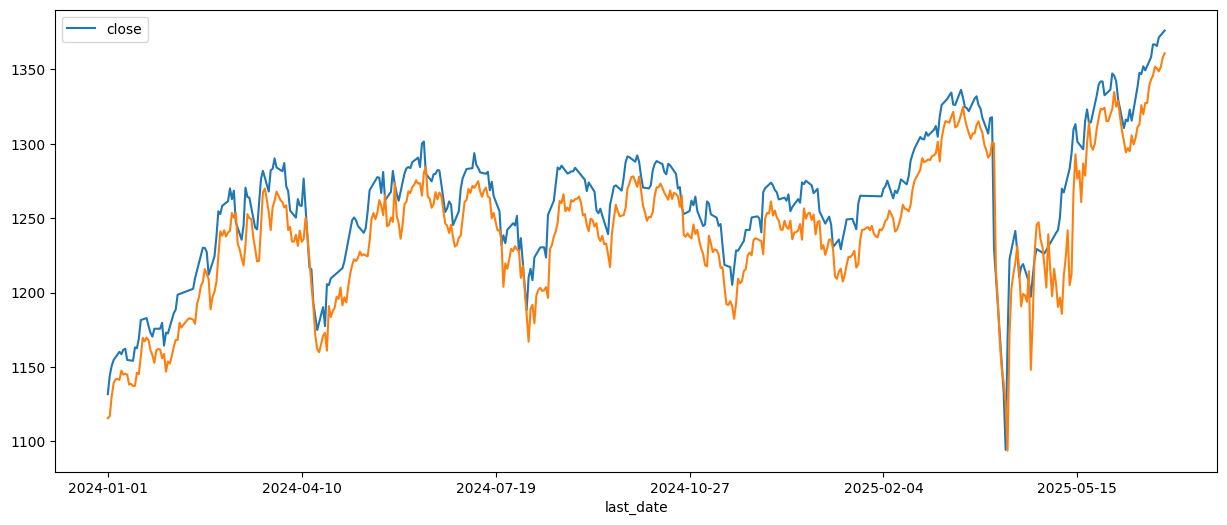

In [55]:
plt.figure(figsize=(15, 6))

y_test.plot(ax=plt.gca())
y_predict.plot(ax=plt.gca(), legend=None, marker=None)

In [56]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict.values.flatten()

In [57]:
# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
# denominator = mean squared difference of actuals
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")

MSE: 512.7680
MAPE: 1.5987 %
RMSSE: 2.4407


In [58]:
NB_NAME = ipynbname.name()
print(NB_NAME)

cnn_vn_index_1


In [59]:
output_dict = {
    "nb_name": NB_NAME,
    "max_timeshift": MAX_TIMESHIFT,
    "min_timeshift": MIN_TIMESHIFT,
    "forecast_horizon": FORECAST_HORIZON,
    "original_features": input_df.columns,
    "selected_feature_count": len(X_train_selected.columns),
    "target": TARGET_COLUMN,
    "train_range": TRAIN_RANGE,
    "validation_range": VALIDATION_RANGE,
    "test_range": TEST_RANGE,
    "max_epochs": MAX_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "patience": PATIENCE,
    "mse": mse,
    "mape": mape,
    "rmsse": rmsse,
}


sorted_output_dict = dict(sorted(output_dict.items()))
sorted_output_dict

{'forecast_horizon': 1,
 'learning_rate': 0.0001,
 'mape': np.float64(1.5987306728459054),
 'max_epochs': 100,
 'max_timeshift': 40,
 'min_timeshift': 40,
 'mse': 512.7679942159021,
 'nb_name': 'cnn_vn_index_1',
 'original_features': Index(['date', 'close', 'stock'], dtype='object'),
 'patience': 10,
 'rmsse': np.float64(2.4407490698977594),
 'selected_feature_count': 375,
 'target': 'close',
 'test_range': ('2024-01-01', '2025-12-31'),
 'train_range': ('2000-01-01', '2021-12-31'),
 'validation_range': ('2022-01-01', '2023-12-31')}

In [60]:
base_filename = f"{NB_NAME}_model_evaluation_results"
extension = ".json"

counter = 1
filename = f"{base_filename}_{counter}{extension}"

# Keep increasing until we find a free filename
while os.path.exists(filename):
    counter += 1
    filename = f"{base_filename}_{counter}{extension}"

with open(filename, "w") as f:
    json.dump(sorted_output_dict, f, indent=4, default=str)

print(f"Saved to: {filename}")

Saved to: cnn_vn_index_1_model_evaluation_results_1.json
